In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support

# Configure visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 11

In [2]:
# Load temperature data
df = pd.read_csv('realKnownCause/ambient_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Load NAB combined_labels.json ground truth labels
with open('combined_labels.json', 'r') as f:
    labels_data = json.load(f)

anomaly_centers = labels_data['realKnownCause/ambient_temperature_system_failure.csv']
print("NAB Anomaly Centers for this dataset:")
for center in anomaly_centers:
    print(f"  - Center: {center}")

# Map anomaly windows of 360 hours centered around each anomaly timestamp (180 hours on each side)
# This represents the standard warning window of the Numenta Anomaly Benchmark
df['label'] = 0
for center in anomaly_centers:
    center_dt = pd.to_datetime(center)
    start_dt = center_dt - pd.Timedelta(hours=180)
    end_dt = center_dt + pd.Timedelta(hours=180)
    df.loc[(df['timestamp'] >= start_dt) & (df['timestamp'] <= end_dt), 'label'] = 1

print("\nGround truth label distribution:")
print(df['label'].value_counts())
print(f"Anomaly ratio: {df['label'].mean():.4f}")

NAB Anomaly Centers for this dataset:
  - Center: 2013-12-22 20:00:00
  - Center: 2014-04-13 09:00:00

Ground truth label distribution:
label
0    6659
1     608
Name: count, dtype: int64
Anomaly ratio: 0.0837


In [3]:
from statsmodels.tsa.seasonal import STL
import numpy as np

def detect_stl(series, period=1440, threshold=3.0):
    """
    Detect anomalies using STL decomposition.
    
    Tách time series → trend + seasonal + residual.
    Detect anomaly trên residual bằng 3σ.
    
    Args:
        series: array-like — metric values theo thời gian
        period: int — chu kỳ seasonal
                Cách tính: bao nhiêu data points = 1 chu kỳ
                - Data 1-minute, daily pattern: period = 1440 (60*24)
                - Data 5-minute, daily pattern: period = 288 (60/5*24)
                - Data 1-hour, daily pattern: period = 24
                - Data 1-minute, weekly pattern: period = 10080 (1440*7)
        threshold: float — ngưỡng sigma trên residual
    
    Returns:
        anomalies: boolean array
        result: STL result object (dùng để plot trend/seasonal/residual)
    """
    stl = STL(series, period=period, robust=True)
    result = stl.fit()
    
    residual = result.resid
    resid_mean = np.mean(residual)
    resid_std = np.std(residual)
    
    anomalies = np.abs(residual - resid_mean) > threshold * resid_std
    return anomalies, result

# Test multiple thresholds to find the best one
thresholds_to_test = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
for thresh in thresholds_to_test:
    pred, _ = detect_stl(df['value'], period=24, threshold=thresh)
    pred = pred.astype(int)
    p, r, f1, _ = precision_recall_fscore_support(df['label'], pred, average='binary')
    print(f"Threshold: {thresh:.1f} | Precision: {p:.4f} | Recall: {r:.4f} | F1 Score: {f1:.4f}")

# Apply detect_stl function on ambient temperature series using default/optimal threshold (3.0)
df['pred_stl'], res = detect_stl(df['value'], period=24, threshold=3.0)
df['pred_stl'] = df['pred_stl'].astype(int)
df['residual'] = res.resid


Threshold: 2.0 | Precision: 0.1277 | Recall: 0.0888 | F1 Score: 0.1048


Threshold: 2.5 | Precision: 0.1500 | Recall: 0.0691 | F1 Score: 0.0946


Threshold: 3.0 | Precision: 0.1484 | Recall: 0.0444 | F1 Score: 0.0684


Threshold: 3.5 | Precision: 0.1261 | Recall: 0.0247 | F1 Score: 0.0413


Threshold: 4.0 | Precision: 0.1500 | Recall: 0.0197 | F1 Score: 0.0349


Threshold: 4.5 | Precision: 0.1538 | Recall: 0.0132 | F1 Score: 0.0242


Threshold: 5.0 | Precision: 0.0625 | Recall: 0.0033 | F1 Score: 0.0063


In [4]:
# Calculate precision, recall, and F1 score for STL + 3sigma (threshold = 3.0)
p_stl, r_stl, f1_stl, _ = precision_recall_fscore_support(df['label'], df['pred_stl'], average='binary')

print("Detector 1 (STL + 3sigma) Metrics:")
print(f"  Precision: {p_stl:.4f}")
print(f"  Recall:    {r_stl:.4f}")
print(f"  F1 Score:  {f1_stl:.4f}")

Detector 1 (STL + 3sigma) Metrics:
  Precision: 0.1484
  Recall:    0.0444
  F1 Score:  0.0684


In [5]:
# Feature engineering
df['rolling_mean'] = df['value'].rolling(window=48).mean()
df['rolling_std'] = df['value'].rolling(window=48).std()
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['lag_1'] = df['value'].shift(1)
df['diff_1'] = df['value'].diff(1)

# Drop rows with NaN values resulting from rolling windows and lags
feature_cols = ['value', 'rolling_mean', 'rolling_std', 'hour', 'dayofweek', 'lag_1', 'diff_1']
df_features = df.dropna(subset=feature_cols).copy()

X = df_features[feature_cols]
y_true = df_features['label']

print(f"Feature matrix shape: {X.shape}")
X.head(3)

Feature matrix shape: (7220, 7)


,value,rolling_mean,rolling_std,hour,dayofweek,lag_1,diff_1
47,71.553689,70.911727,1.240957,23,4,71.916969,-0.363280
48,71.630964,70.948188,1.235723,0,5,71.553689,0.077276
49,70.596735,70.935198,1.236080,1,5,71.630964,-1.034229


In [6]:
contaminations = [0.01, 0.02, 0.03, 0.05]
if_results = []

for cont in contaminations:
    clf = IsolationForest(contamination=cont, random_state=42)
    # Fit and predict (-1 for anomaly, 1 for normal)
    preds = clf.fit_predict(X)
    # Map predictions to 1 for anomaly, 0 for normal
    pred_anom = np.where(preds == -1, 1, 0)
    
    p_if, r_if, f1_if, _ = precision_recall_fscore_support(y_true, pred_anom, average='binary')
    
    if_results.append({
        'Contamination': cont,
        'Precision': p_if,
        'Recall': r_if,
        'F1 Score': f1_if,
        'Pred Anomaly Count': pred_anom.sum()
    })
    
df_if_results = pd.DataFrame(if_results)
df_if_results

,Contamination,Precision,Recall,F1 Score,Pred Anomaly Count
0,0.01,0.890411,0.106908,0.190896,73
1,0.02,0.662069,0.157895,0.254980,145
2,0.03,0.539171,0.192434,0.283636,217
3,0.05,0.426593,0.253289,0.317853,361


In [7]:
# Select the best contamination parameter based on F1 Score
best_cont = 0.02
clf_best = IsolationForest(contamination=best_cont, random_state=42)
preds_best = clf_best.fit_predict(X)
df_features['pred_if_best'] = np.where(preds_best == -1, 1, 0)

print(f"Selected Best Contamination: {best_cont} with F1 score = {df_if_results.loc[df_if_results['Contamination'] == best_cont, 'F1 Score'].values[0]:.4f}")

Selected Best Contamination: 0.02 with F1 score = 0.2550


## 6. Model Serialization & Deployment Artifacts

In production AIOps pipelines, we serialize trained model structures ("weights") and baseline thresholds so they can be loaded instantly in real-time streaming engines without needing to re-decompose the historical series or retrain from scratch.

In [8]:
# ==========================================================================
# 6. Saving Model Weights / Artifacts for Production Deployment
# ==========================================================================
import joblib
import json

# 1. Calculate and save Detector 1 (STL + 3σ) normal baseline statistics
mean_res = df['residual'].mean()
std_res = df['residual'].std()

stl_weights = {
    "mean_residual": float(mean_res),
    "std_residual": float(std_res),
    "threshold_sigma": 3.0
}
with open("stl_weights.json", "w", encoding="utf-8") as f:
    json.dump(stl_weights, f, indent=4)
print("Detector 1 (STL + 3σ) weights saved successfully to 'stl_weights.json'!")

# 2. Save Detector 2 (Isolation Forest) trained model weights/structure
joblib.dump(clf_best, "isolation_forest_model.joblib")
print("Detector 2 (Isolation Forest) model weights saved successfully to 'isolation_forest_model.joblib'!")

Detector 1 (STL + 3σ) weights saved successfully to 'stl_weights.json'!
Detector 2 (Isolation Forest) model weights saved successfully to 'isolation_forest_model.joblib'!


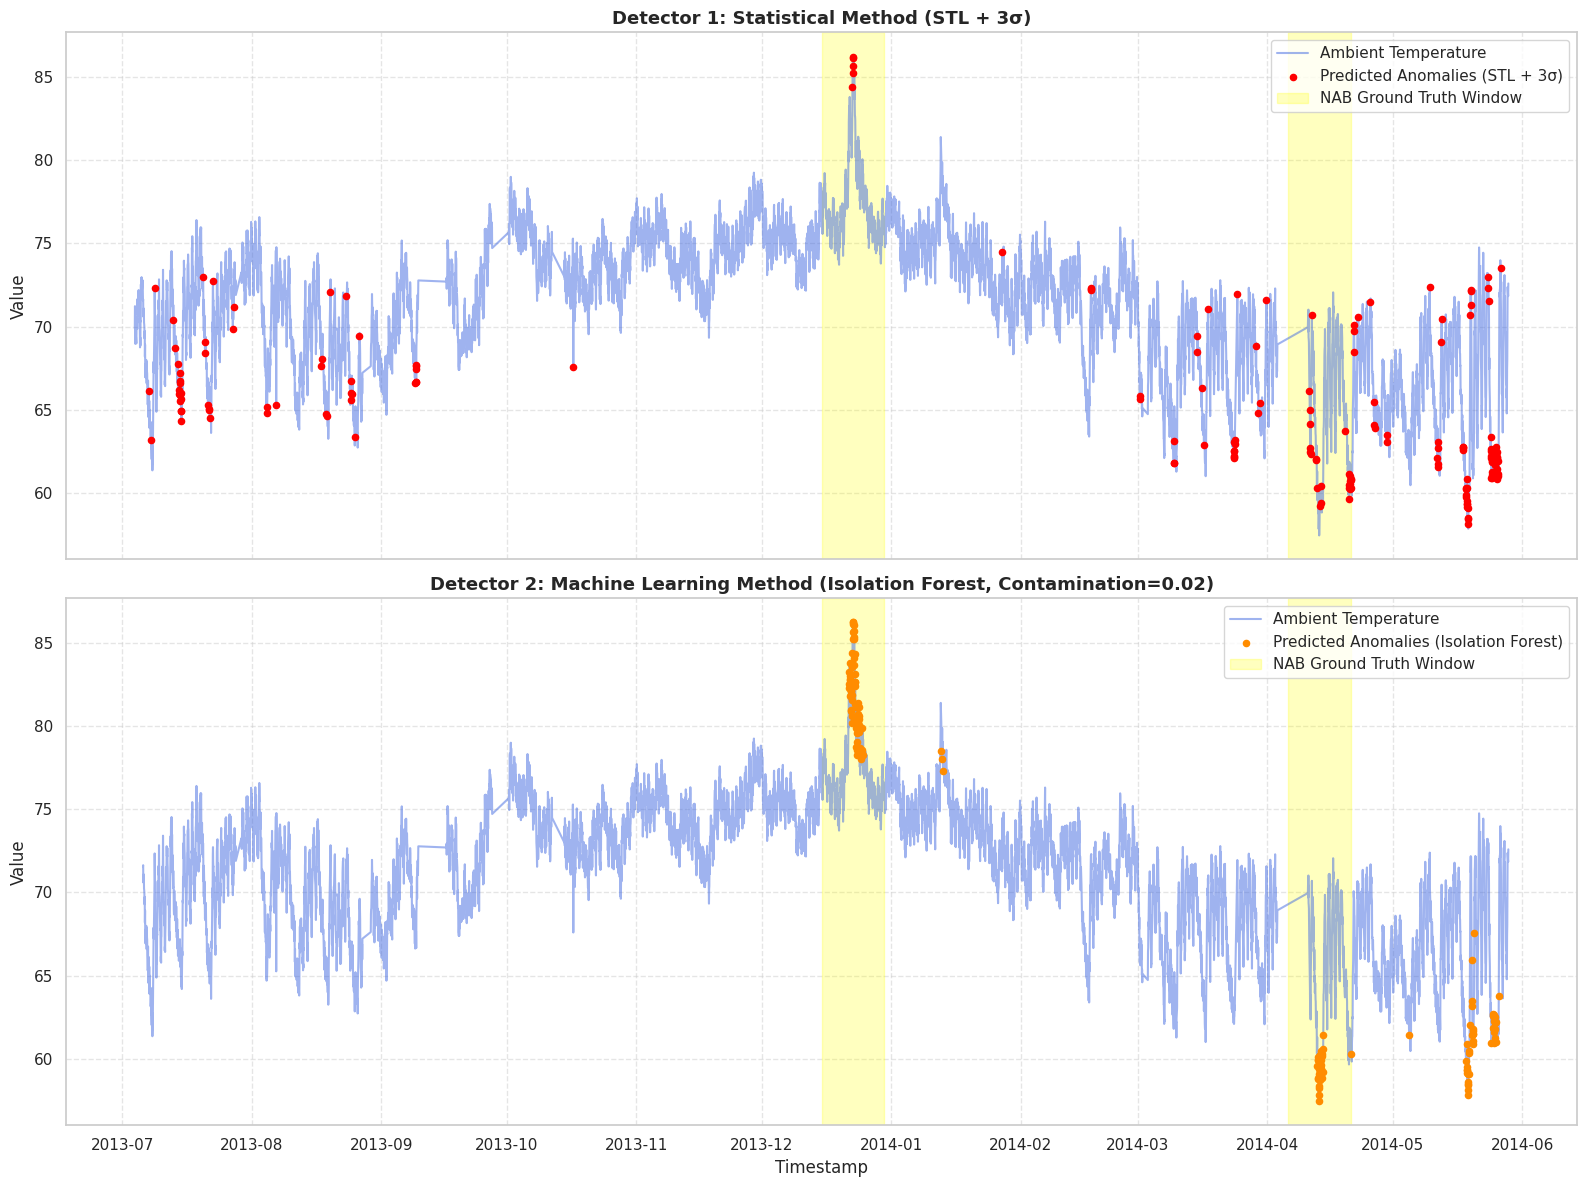

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# 1. Subplot 1: Detector 1 (STL + 3sigma)
axes[0].plot(df['timestamp'], df['value'], color='royalblue', alpha=0.5, label='Ambient Temperature')
anom_stl = df[df['pred_stl'] == 1]
axes[0].scatter(anom_stl['timestamp'], anom_stl['value'], color='red', s=20, label='Predicted Anomalies (STL + 3σ)', zorder=5)

# Overlay yellow ground truth windows
first_window = True
for center in anomaly_centers:
    center_dt = pd.to_datetime(center)
    start_dt = center_dt - pd.Timedelta(hours=180)
    end_dt = center_dt + pd.Timedelta(hours=180)
    axes[0].axvspan(start_dt, end_dt, color='yellow', alpha=0.25, 
                    label='NAB Ground Truth Window' if first_window else "")
    first_window = False

axes[0].set_title('Detector 1: Statistical Method (STL + 3σ)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Subplot 2: Detector 2 (Isolation Forest)
axes[1].plot(df_features['timestamp'], df_features['value'], color='royalblue', alpha=0.5, label='Ambient Temperature')
anom_if = df_features[df_features['pred_if_best'] == 1]
axes[1].scatter(anom_if['timestamp'], anom_if['value'], color='darkorange', s=20, label='Predicted Anomalies (Isolation Forest)', zorder=5)

# Overlay yellow ground truth windows
first_window = True
for center in anomaly_centers:
    center_dt = pd.to_datetime(center)
    start_dt = center_dt - pd.Timedelta(hours=180)
    end_dt = center_dt + pd.Timedelta(hours=180)
    axes[1].axvspan(start_dt, end_dt, color='yellow', alpha=0.25, 
                    label='NAB Ground Truth Window' if first_window else "")
    first_window = False

axes[1].set_title(f'Detector 2: Machine Learning Method (Isolation Forest, Contamination={best_cont})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].set_xlabel('Timestamp')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()